# AAI614: Data Science & its Applications

*Notebook 8.4: Classifying Sentiments in Arabizi*

<a href="https://colab.research.google.com/drive/18vcVWya3lAKvRFMwp_rVwT3MIO_2wXq8?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please check the following [paper](https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf) for reference purposes.

In [10]:
import io
import pandas as pd
import re
import csv
from random import shuffle
import numpy as np
import matplotlib.pyplot as plt
import ssl
from sklearn.feature_extraction.text import TfidfVectorizer

ssl._create_default_https_context = ssl._create_unverified_context

In [20]:
ARABIZI_FILE = "https://raw.githubusercontent.com/harmanani/AAI614/refs/heads/main/Week%208/2-class-sentiment-arabizi.csv"
csvfile = pd.read_csv(ARABIZI_FILE)
csvfile


,tweet,sentiment,highlight
0,@Douniakatibi eh ktir bahdaleeeeee,Negative,NaN
1,Shu b7bk ya beirut 😍❤️🌲,Positive,Courtesy words
2,L liste shwe ktir mesh zabta,Negative,NaN
3,@trissaabiissa ktir helo ltalej bs bye7la bo w...,Positive,NaN
4,akh ya allah ghachaytine dehek hahahaha,Positive,NaN
...,...,...,...
1195,Lakk ya 1000 halaaa 🤣😍 ehh hayda 7akee 🤣,Positive,NaN
1196,Knt ktir yenzal dam rehet al hospital w kouwyo...,Positive,NaN
1197,@fadelkaadan anna bi beirut bas raj3anee 3a Mi...,Negative,NaN
1198,Sma3et sot bel beit mich mestarjeye odhar men ...,Negative,NaN


As you can see, each data point is composed of a tweet, a sentiment label, and a highlight.  The highlight will not be used in this code.

## Defining useful global variables

Next you will define some global variables that will be used throughout the assignment.

- `NUM_WORDS`: The maximum number of words to keep, based on word frequency. Defaults to 2000.


- `EMBEDDING_DIM`: Dimension of the dense embedding, will be used in the embedding layer of the model. Defaults to 16.


- `MAXLEN`: Maximum length of all sequences. Defaults to 120.


- `PADDING`: Padding strategy (pad either before or after each sequence.). Defaults to 'post'.


- `OOV_TOKEN`: Token to replace out-of-vocabulary words during text_to_sequence calls. Defaults to "\<OOV>".

    
- `TRAINING_SPLIT`: Proportion of data used for training. Defaults to 0.8

**For now leave them unchanged but after submitting your assignment for grading you are encouraged to come back here and play with these parameters to see the impact they have in the classification process**

In [12]:
TRAINING_SPLIT = 0.8
RANDOM_SEED = 42
MAX_FEATURES = 2000  # Limit TF-IDF to top 2000 tokens


## Loading and pre-processing the data

Now you should code the functions to remove stopwords from text and to load the data from a csv file.

Since you already coded these functions for the previous week, these are provided for you.

In [13]:
def remove_stopwords(sentence):
    # List of stopwords
    stopwords = ['chu', 'chou', 'hal', 'chou', 'fikeee', 'eh', 'ma', '3a', '3am', '3an', '3ana', '3endon', '3m', 'aal', '3al','3ala','al', 'ana',
                 'b', 'bas', 'bel', 'bi', 'chi', 'el', 'ele', 'enn', 'enno', 'eno', 'mch', '3layki', '3layon',
                 'enta', 'enteh', 'eza', 'fi', 'fik', 'fina', 'fine', 'fiya', 'fiye', 'wlik', 'shi',
                 'hal', 'hayda', 'hek', 'inta', 'iza', 'kaza', 'kel', 'kente', 'kif',
                 'kint', 'kinte', 'l', 'la', 'la2na', 'lal', 'li', 'ma3', 'ma3a', 'ma3ak',
                 'ma3e', 'ma3ekk', 'ma3i', 'ma3ik', 'ma3ke', 'ma3na', 'ma3o', 'men', 'mn',
                 'n7na', 'shu', 'tab', 'tayeb', 'w', 'wlek', 'ya', 'ya3ne', 'yala', 'yalle']

    # Sentence converted to lowercase-only
    sentence = sentence.lower()

    words = sentence.split()
    no_words = [w for w in words if w not in stopwords]
    sentence = " ".join(no_words)

    return sentence

In [14]:
def clean_tweet(tweet):

    #if isinstance(tweet, float):
    #  return ""
    temp = tweet.lower()
    temp = re.sub("'", "", temp) # to avoid removing contractions in english
    temp = re.sub("@[A-Za-z0-9_]+","", temp)
    temp = re.sub("#[A-Za-z0-9_]+","", temp)
    temp = re.sub(r'http\S+', '', temp)
    temp = re.sub('[()!?]', ' ', temp)
    temp = re.sub('\[.*?\]',' ', temp)
    temp = re.sub("[^a-z0-9]"," ", temp)
    temp = re.sub(r"h[ha]{3,}", "hahaha", temp)
    temp = re.sub(r"lo{1,}l", "lol", temp)
    return temp

In [17]:
def parse_data_from_url(url):
    df = pd.read_csv(url)
    sentences = []
    sentiments = []

    for _, row in df.iterrows():
        sentence = remove_stopwords(row[0])
        sentence = clean_tweet(sentence)
        sentences.append(sentence)
        sentiments.append(row[1])

    return sentences, sentiments


In [21]:
# Load and preprocess the data
sentences, sentiments = parse_data_from_url(ARABIZI_FILE)

# Shuffle the data
temp = list(zip(sentences, sentiments))
shuffle(temp)
sentences, sentiments = zip(*temp)
sentences, sentiments = list(sentences), list(sentiments)

# Print summary
print(f"There are {len(sentences)} sentences in the dataset.\n")
print(f"First sentence has {len(sentences[0].split())} words (after cleaning).\n")
print(f"First sentence has the following words: {sentences[0].split()}.\n")
print(f"There are {len(sentiments)} sentiment labels in the dataset.\n")
print(f"The first 5 labels are {sentiments[:5]}")


There are 1200 sentences in the dataset.

First sentence has 10 words (after cleaning).

First sentence has the following words: ['dude', 'aratet', 'de7ek', 'wa2ta', 'fetet', '3layyon', 'like', 'uhm', 'the', 'fuck'].

There are 1200 sentiment labels in the dataset.

The first 5 labels are ['Positive', 'Positive', 'Positive', 'Negative', 'Positive']


/tmp/ipython-input-17-3146386722.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sentence = remove_stopwords(row[0])
/tmp/ipython-input-17-3146386722.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sentiments.append(row[1])


## Training - Validation Split

`train_val_split`, which given the list of sentences, the list of labels and the proportion of data for the training set, returns the training and validation sentences and labels:

In [22]:
def train_val_split(sentences, labels, training_split):

    # Compute the number of sentences that will be used for training (should be an integer)
    train_size = int(len(sentences) * training_split) # YOUR CODE HERE

    # Split the sentences and labels into train/validation splits
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]

    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]

    return train_sentences, validation_sentences, train_labels, validation_labels

In [23]:
# Split the data
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, sentiments, TRAINING_SPLIT)

# Display split summary
print(f"The longest tweet is {max(len(x.split()) for x in sentences)} words long!\n")
print(f"There are {len(train_sentences)} sentences for training.")
print(f"There are {len(train_labels)} labels for training.\n")
print(f"There are {len(val_sentences)} sentences for validation.")
print(f"There are {len(val_labels)} labels for validation.")


The longest tweet is 45 words long!

There are 960 sentences for training.
There are 960 labels for training.

There are 240 sentences for validation.
There are 240 labels for validation.


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_train = vectorizer.fit_transform(train_sentences)
X_val = vectorizer.transform(val_sentences)


In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels)
y_val = label_encoder.transform(val_labels)


## Selecting the model for text classification

Now that the data is ready to be fed a Neural Network it is time for you to define the model that will classify each text as being part of a certain category.

For this complete the `create_model` below.

A couple of things to keep in mind:

- Notice that this function has three parameters, all of which are meant to be passed to an [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer, which is what you will probably use as a first layer for your model.


- The last layer should be a Dense layer with 5 units (since there are 5 categories) with a softmax activation.


- You should also compile your model using an appropiate loss function and optimizer.


- You can use any architecture you want but keep in mind that this problem doesn't need many layers to be solved successfully. You don't need any layers beside Embedding, [GlobalAveragePooling1D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling1D) and Dense layers but feel free to try out different architectures.

In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the SVM classifier
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict on validation data
y_pred = svm_model.predict(X_val)

# Evaluate performance
accuracy = accuracy_score(y_val, y_pred)
print(f"SVM Validation Accuracy: {accuracy:.4f}\n")

# Detailed performance report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


SVM Validation Accuracy: 0.6833

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.71      0.69       117
    Positive       0.70      0.66      0.68       123

    accuracy                           0.68       240
   macro avg       0.68      0.68      0.68       240
weighted avg       0.68      0.68      0.68       240

Confusion Matrix:
[[83 34]
 [42 81]]


Once training has finished you can run the following cell to check the training and validation accuracy achieved at the end of each epoch.

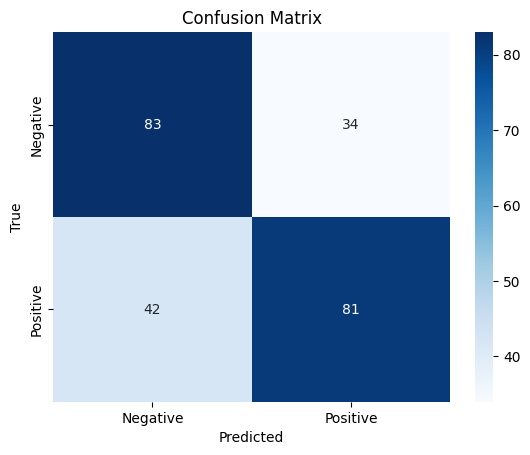

In [28]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
